# Checkpoint 4 

This notebook contains supplementary code and data for the problems accompanying Checkpoint 4. You can find the full Checkpoint in [Gradescope](https://www.gradescope.com/courses/1181817/assignments/7359124/).

**Task:** Write a function named `gdp_and_population_ratio` that takes the countries GeoDataFrame and makes a plot with two subplots. The first subplot should show the ratio of the population that lives in each country as the color. The second subplot should show the ratio of the world GDP that each country has. To do this, you are allowed to add new columns to the dataset called `pop_ratio` and `gdp_ratio`.

The plot should include a legend. The legend should be scaled so the minimum value is 0 (`vmin=0`) and the maximum value is 1 (`vmax=1`). Finally, make sure the figsize is set to `figsize=(15, 10)`!

You do not need to save the figure, but calling `gdp_and_population_ratio` should show the figure that you have created.

> **HINT:** Since this dataset also contains geospatial data, running `countries.head()` may not produce a useful output. In order to find which columns you might want to use, you can use the `countries.columns` properties to inspect what columns are in the dataset. Remember that we are interested in the `GDP` and the population aspects of the dataset, so the columns you are looking for should contain `GDP` and `POP` respectively.

> The file path for the `.shp` file is given relative to its location in JupyterHub. If you want to work locally, make sure to download the `geo_data.zip` folder, unzip its contents, and update any file paths so that they match your local setup!

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

%matplotlib inline

countries = gpd.read_file('/home/jovyan/materials/lessons/geo_data/ne_110m_admin_0_countries.shp')

In [15]:
def gdp_and_population_ratio(countries):
    # Creating a copy to avoid SettingWithCopyWarning
    countries = countries.copy()
    
    # Updated column names to match the Natural Earth dataset schema
    pop_col = 'POP_EST'
    gdp_col = 'GDP_MD_EST'
    
    # Calculate totals
    total_pop = countries[pop_col].sum()
    total_gdp = countries[gdp_col].sum()
    
    # Calculate ratios
    countries['pop_ratio'] = countries[pop_col] / total_pop
    countries['gdp_ratio'] = countries[gdp_col] / total_gdp
    
    # Initialize the figure with the required figsize
    fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15, 10))
    
    # Plot Population Ratio
    countries.plot(column='pop_ratio', ax=ax1, legend=True, vmin=0, vmax=1)
    ax1.set_title('Population Ratio')
    
    # Plot GDP Ratio
    countries.plot(column='gdp_ratio', ax=ax2, legend=True, vmin=0, vmax=1)
    ax2.set_title('GDP Ratio')
    
    plt.show()

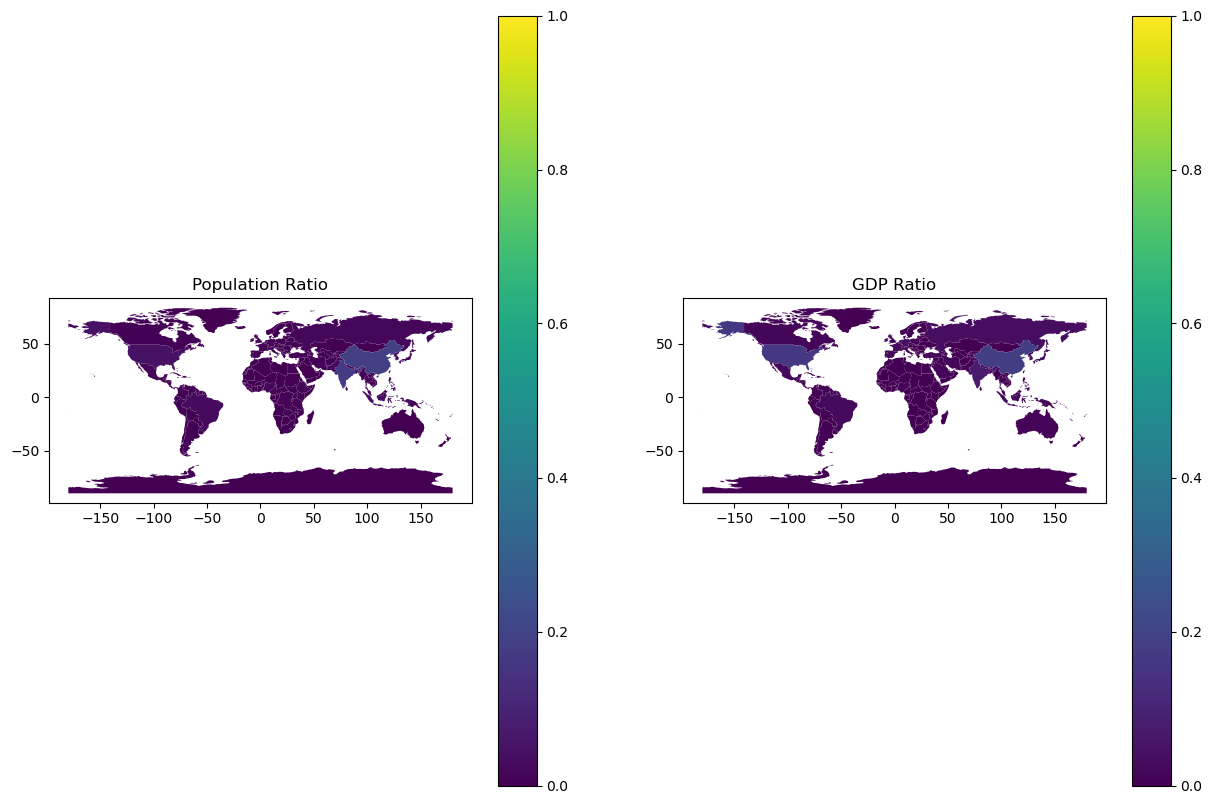

In [16]:
gdp_and_population_ratio(countries)